# Poisson Point Process

A **Poisson point process** is the simplest and most fundamental model for random events 
occurring in time or space. It answers the question: "If events happen randomly and 
independently, what does the pattern look like?"

## Definition (1D Temporal)

A counting process $N(t)$ = number of events in $[0, t]$ is a **Poisson process** with rate 
$\lambda > 0$ if:

1. **$N(0) = 0$**
2. **Independent increments**: Events in disjoint intervals are independent
3. **Poisson distribution**: $N(t) - N(s) \sim \text{Poisson}(\lambda(t-s))$

## The Two Equivalent Constructions

| Construction | Description |
|-------------|-------------|
| **Inter-arrival times** | $\tau_i \sim \text{Exp}(\lambda)$ i.i.d., then $T_n = \sum_{i=1}^n \tau_i$ |
| **Direct generation** | $N(t) \sim \text{Poisson}(\lambda t)$, then uniform conditional times |

Both give the same process! This is a remarkable property of the Poisson process.


## Key Properties

### 1. Inter-Arrival Times are Exponential

$$\tau_i \sim \text{Exp}(\lambda) \quad \Rightarrow \quad P(\tau_i > t) = e^{-\lambda t}$$

**Mean inter-arrival time**: $\mathbb{E}[\tau] = \frac{1}{\lambda}$

### 2. Counting Distribution

$$P(N(t) = k) = \frac{(\lambda t)^k}{k!} e^{-\lambda t}$$

**Mean**: $\mathbb{E}[N(t)] = \lambda t$
**Variance**: $\text{Var}(N(t)) = \lambda t$

> **Important**: Mean = Variance. This is the signature of a Poisson process. 
> If you observe data where variance >> mean, it's **overdispersed** and not Poisson.

### 3. Memoryless Property

$$P(\tau > s + t \mid \tau > s) = P(\tau > t)$$

The waiting time doesn't "remember" how long you've already waited. This is unique 
to the exponential distribution.

### 4. Superposition

If $N_1(t)$ has rate $\lambda_1$ and $N_2(t)$ has rate $\lambda_2$ (independent), 
then $N_1(t) + N_2(t)$ is Poisson with rate $\lambda_1 + \lambda_2$.

### 5. Thinning

If each event of a Poisson process with rate $\lambda$ is kept with probability $p$ 
(independently), the result is Poisson with rate $\lambda p$.


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def simulate_poisson_process(lam=1.0, T=10.0, n_paths=1, seed=None):
    """
    Simulate homogeneous Poisson process with rate lambda.
    
    Uses the inter-arrival time method:
    - Generate Exp(lambda) inter-arrival times
    - Cumsum to get arrival times
    - Build counting process N(t)
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Generate enough inter-arrival times
    expected = int(lam * T * 1.5) + 100
    all_arrivals = []
    
    for _ in range(n_paths):
        inter_arrivals = np.random.exponential(1.0 / lam, size=expected)
        arrivals = np.cumsum(inter_arrivals)
        arrivals = arrivals[arrivals <= T]  # Truncate to [0, T]
        all_arrivals.append(arrivals)
    
    # Build counting process on a fine grid
    t_grid = np.linspace(0, T, 1000)
    N = np.zeros((n_paths, len(t_grid)))
    
    for i, arrivals in enumerate(all_arrivals):
        for j, t in enumerate(t_grid):
            N[i, j] = np.sum(arrivals <= t)
    
    return t_grid, N, all_arrivals

# Quick test
t, N, arrivals = simulate_poisson_process(lam=2.0, T=5.0, n_paths=1, seed=42)
print(f"Arrival times: {arrivals[0][:10]}")
print(f"N(5) = {N[0, -1]}")
print(f"Expected N(5) = 2.0 * 5 = 10")


Arrival times: [0.23463404 1.73969476 2.39806761 2.85453888 2.93935132 3.02414947
 3.05406885 4.05968428 4.51922536]
N(5) = 9.0
Expected N(5) = 2.0 * 5 = 10


## Visualizing the Counting Process

$N(t)$ is a **step function** that jumps by 1 at each arrival time. The slope of $N(t)$ 
is approximately $\lambda$ — the average rate of events.

## Inter-Arrival Times

The histogram of inter-arrival times should match the exponential PDF:

$$f(t) = \lambda e^{-\lambda t}$$

The mean should be $1/\lambda$. This is a critical diagnostic — if your data doesn't 
have exponentially distributed gaps, it's not a Poisson process.


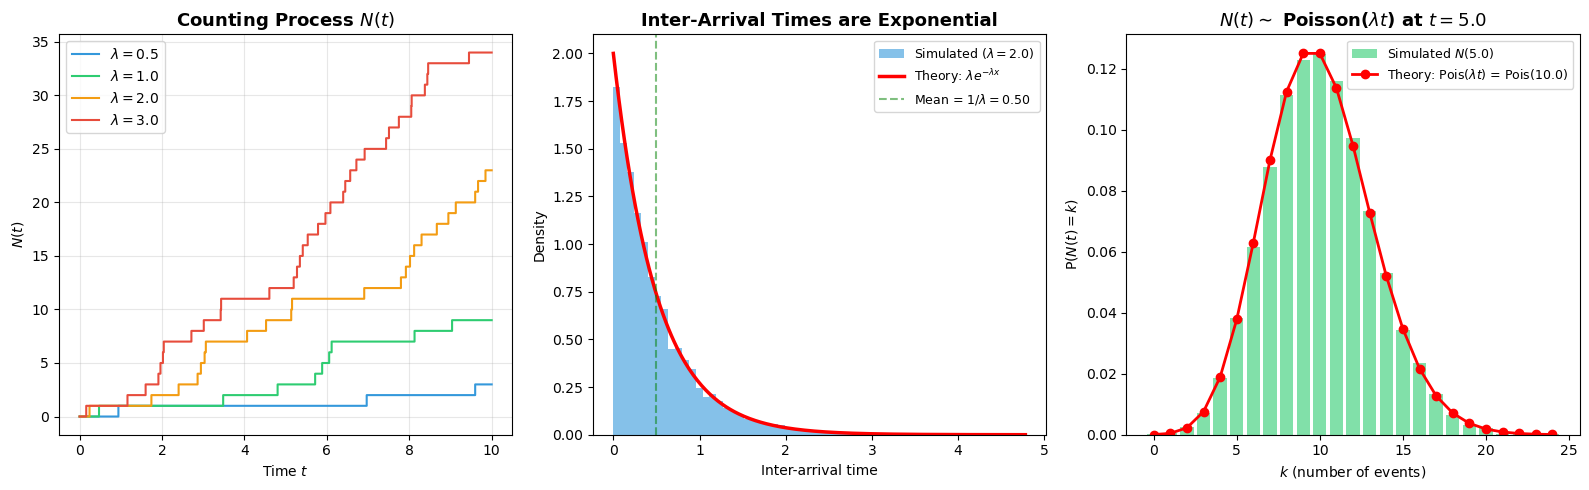

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Left: Counting process for different lambda ---
ax = axes[0]
rates = [0.5, 1.0, 2.0, 3.0]
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

for lam, color in zip(rates, colors):
    t_grid, N, _ = simulate_poisson_process(lam=lam, T=10.0, n_paths=1, seed=42)
    ax.step(t_grid, N[0], where='post', color=color, linewidth=1.5, label=rf'$\lambda = {lam}$')

ax.set_title('Counting Process $N(t)$', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$')
ax.set_ylabel('$N(t)$')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Middle: Inter-arrival times ---
ax = axes[1]
np.random.seed(55)
lam = 2.0
inter_arrivals = np.random.exponential(1.0 / lam, size=10000)

ax.hist(inter_arrivals, bins=60, density=True, alpha=0.6, color='#3498db', 
        label=rf'Simulated ($\lambda = {lam}$)')
x_range = np.linspace(0, max(inter_arrivals), 300)
theory_pdf = lam * np.exp(-lam * x_range)
ax.plot(x_range, theory_pdf, 'r-', linewidth=2.5, label=rf'Theory: $\lambda e^{{-\lambda x}}$')
ax.axvline(x=1/lam, color='green', linestyle='--', alpha=0.5, label=rf'Mean = $1/\lambda = {1/lam:.2f}$')
ax.set_title('Inter-Arrival Times are Exponential', fontsize=13, fontweight='bold')
ax.set_xlabel('Inter-arrival time')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

# --- Right: N(t) distribution at fixed t ---
ax = axes[2]
np.random.seed(66)
lam = 2.0
T_fixed = 5.0
n_sims = 10000

N_T = [np.random.poisson(lam * T_fixed) for _ in range(n_sims)]
ax.hist(N_T, bins=range(0, max(N_T)+2), density=True, alpha=0.6, color='#2ecc71', 
        align='left', rwidth=0.8, label=rf'Simulated $N({T_fixed})$')

k_range = np.arange(0, max(N_T)+1)
theory_pmf = stats.poisson.pmf(k_range, lam * T_fixed)
ax.plot(k_range, theory_pmf, 'ro-', markersize=6, linewidth=2, 
        label=rf'Theory: Pois($\lambda t$) = Pois({lam*T_fixed})')
ax.set_title(rf'$N(t) \sim$ Poisson($\lambda t$) at $t={T_fixed}$', fontsize=13, fontweight='bold')
ax.set_xlabel('$k$ (number of events)')
ax.set_ylabel('P($N(t) = k$)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## Superposition and Thinning

### Superposition: Adding Two Poisson Processes

If $N_1(t) \sim \text{Poisson}(\lambda_1)$ and $N_2(t) \sim \text{Poisson}(\lambda_2)$ are 
independent, then:

$$N_1(t) + N_2(t) \sim \text{Poisson}(\lambda_1 + \lambda_2)$$

**Intuition**: Two independent streams of customers arriving at a shop combine into 
one stream with the sum of the rates.

### Thinning: Randomly Removing Events

If each event of a Poisson process with rate $\lambda$ is kept with probability $p$:

$$N_{\text{kept}}(t) \sim \text{Poisson}(\lambda p)$$

**Intuition**: If customers arrive as Poisson and each buys with probability $p$, 
the purchases are also Poisson (just slower).

> **Key insight**: The Poisson process is closed under superposition and thinning. 
> This makes it incredibly tractable for modeling.


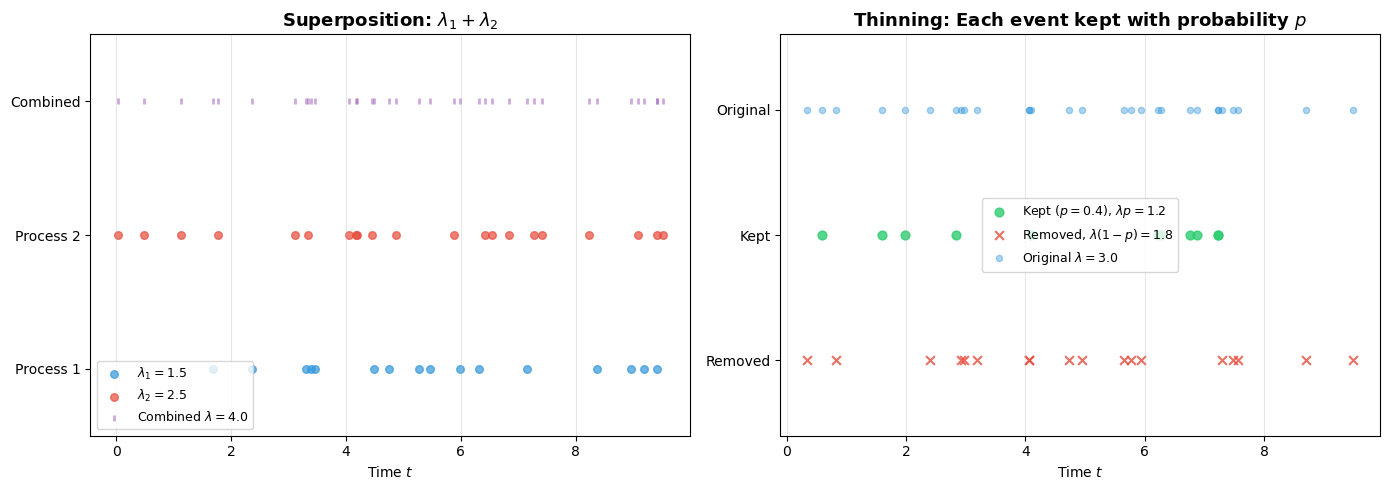

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Superposition ---
ax = axes[0]
np.random.seed(77)
T = 10.0
lam1, lam2 = 1.5, 2.5

_, _, arr1 = simulate_poisson_process(lam=lam1, T=T, n_paths=1, seed=77)
_, _, arr2 = simulate_poisson_process(lam=lam2, T=T, n_paths=1, seed=78)
combined = np.sort(np.concatenate([arr1[0], arr2[0]]))

y1 = np.ones(len(arr1[0]))
y2 = np.ones(len(arr2[0])) * 2
y_combined = np.ones(len(combined)) * 3

ax.scatter(arr1[0], y1, color='#3498db', s=30, alpha=0.7, label=rf'$\lambda_1 = {lam1}$')
ax.scatter(arr2[0], y2, color='#e74c3c', s=30, alpha=0.7, label=rf'$\lambda_2 = {lam2}$')
ax.scatter(combined, y_combined, color='#9b59b6', s=15, alpha=0.5, marker='|', 
           linewidths=2, label=rf'Combined $\lambda = {lam1+lam2}$')
ax.set_title(rf'Superposition: $\lambda_1 + \lambda_2$', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$')
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['Process 1', 'Process 2', 'Combined'])
ax.set_ylim(0.5, 3.5)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

# --- Right: Thinning ---
ax = axes[1]
np.random.seed(88)
lam = 3.0
_, _, arrivals = simulate_poisson_process(lam=lam, T=10.0, n_paths=1, seed=88)
arr = arrivals[0]

p = 0.4
keep = np.random.rand(len(arr)) < p
kept = arr[keep]
removed = arr[~keep]

ax.scatter(kept, np.ones(len(kept)), color='#2ecc71', s=40, alpha=0.8, 
           label=rf'Kept ($p={p}$), $\lambda p = {lam*p:.1f}$')
ax.scatter(removed, np.ones(len(removed)) * 0.5, color='#e74c3c', s=40, alpha=0.8, 
           marker='x', label=rf'Removed, $\lambda(1-p) = {lam*(1-p):.1f}$')
ax.scatter(arr, np.ones(len(arr)) * 1.5, color='#3498db', s=20, alpha=0.4, 
           label=rf'Original $\lambda = {lam}$')
ax.set_title('Thinning: Each event kept with probability $p$', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$')
ax.set_yticks([0.5, 1.0, 1.5])
ax.set_yticklabels(['Removed', 'Kept', 'Original'])
ax.set_ylim(0.2, 1.8)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


## The Waiting Time Paradox (Bus Paradox)

You arrive at a bus stop at a random time. Buses arrive as a Poisson process with 
rate $\lambda$. How long do you wait?

### Naive Answer

"The average gap between buses is $1/\lambda$, so I wait about $1/(2\lambda)$ on average."

### Correct Answer

"You wait $1/\lambda$ on average — the **same** as the mean inter-arrival time!"

### Why?

Because you're more likely to arrive during a **long** gap than a short gap. 
The probability of landing in a gap of length $\tau$ is proportional to $\tau$.

### The Memoryless Property

$$P(\text{wait} > t \mid \text{already waited } s) = P(\text{wait} > t) = e^{-\lambda t}$$

The exponential distribution "doesn't remember" how long you've been waiting. 
This is why the residual waiting time has the same distribution as a fresh inter-arrival time.

### Forward and Backward Waiting Times

Both are exponentially distributed with rate $\lambda$:

- **Forward**: Time to next bus
- **Backward**: Time since last bus

Both $\sim \text{Exp}(\lambda)$, independent of each other!


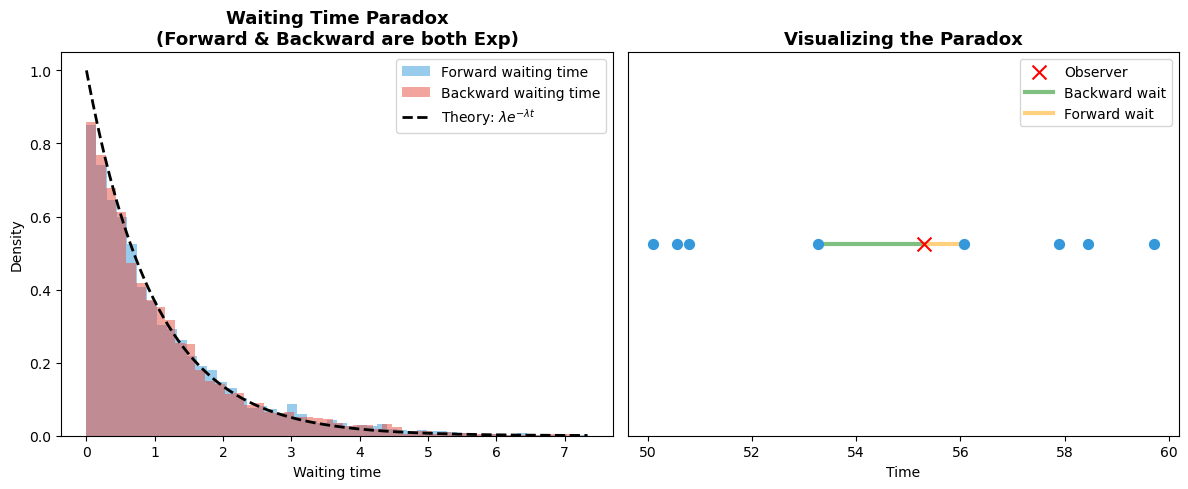

Mean forward wait: 1.123 (theory: 1.000)
Mean backward wait: 1.102 (theory: 1.000)
Mean inter-arrival: 1.085 (theory: 1.000)


In [25]:
np.random.seed(99)
lam = 1.0
T_large = 1000.0
_, _, arrivals_large = simulate_poisson_process(lam=lam, T=T_large, n_paths=1, seed=99)
arr = arrivals_large[0]

# Pick random observation points
n_obs = 5000
obs_times = np.random.uniform(1, T_large-1, n_obs)

forward_times = []
backward_times = []
for obs in obs_times:
    next_idx = np.searchsorted(arr, obs)
    if next_idx < len(arr):
        forward_times.append(arr[next_idx] - obs)
    if next_idx > 0:
        backward_times.append(obs - arr[next_idx - 1])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(forward_times, bins=50, density=True, alpha=0.5, color='#3498db', label='Forward waiting time')
plt.hist(backward_times, bins=50, density=True, alpha=0.5, color='#e74c3c', label='Backward waiting time')
x_range = np.linspace(0, max(forward_times + backward_times), 300)
plt.plot(x_range, lam * np.exp(-lam * x_range), 'k--', linewidth=2, 
         label=rf'Theory: $\lambda e^{{-\lambda t}}$')
plt.title('Waiting Time Paradox\n(Forward & Backward are both Exp)', fontsize=13, fontweight='bold')
plt.xlabel('Waiting time')
plt.ylabel('Density')
plt.legend(fontsize=10)

plt.subplot(1, 2, 2)
# Show a segment with an observation point
segment_start = 50
segment_end = 60
segment_arrivals = arr[(arr > segment_start) & (arr < segment_end)]
obs_example = 55.3

plt.scatter(segment_arrivals, np.zeros(len(segment_arrivals)), color='#3498db', s=50, zorder=5)
plt.scatter([obs_example], [0], color='red', s=100, marker='x', zorder=5, label='Observer')
prev_bus = segment_arrivals[segment_arrivals < obs_example][-1] if any(segment_arrivals < obs_example) else None
next_bus = segment_arrivals[segment_arrivals > obs_example][0] if any(segment_arrivals > obs_example) else None
if prev_bus:
    plt.plot([prev_bus, obs_example], [0, 0], 'g-', linewidth=3, alpha=0.5, label='Backward wait')
if next_bus:
    plt.plot([obs_example, next_bus], [0, 0], 'orange', linewidth=3, alpha=0.5, label='Forward wait')
plt.title('Visualizing the Paradox', fontsize=13, fontweight='bold')
plt.xlabel('Time')
plt.yticks([])
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean forward wait: {np.mean(forward_times):.3f} (theory: {1/lam:.3f})")
print(f"Mean backward wait: {np.mean(backward_times):.3f} (theory: {1/lam:.3f})")
print(f"Mean inter-arrival: {np.mean(np.diff(arr)):.3f} (theory: {1/lam:.3f})")


## Inhomogeneous Poisson Process

When the event rate varies with time: $\lambda(t)$.

### Definition

$N(t)$ is an inhomogeneous Poisson process with rate function $\lambda(t) \geq 0$ if:

1. $N(0) = 0$
2. Independent increments
3. $N(t) - N(s) \sim \text{Poisson}\left(\int_s^t \lambda(u) \, du\right)$

### Simulation by Thinning

1. Find $\lambda_{\max} = \max_{t \in [0,T]} \lambda(t)$
2. Generate homogeneous Poisson process with rate $\lambda_{\max}$
3. Keep event at time $t$ with probability $\lambda(t) / \lambda_{\max}$

### Example

$$\lambda(t) = 1 + 2\sin(t)$$

- High activity when $\sin(t) > 0$ (morning rush hour?)
- Low activity when $\sin(t) < 0$ (night time?)
- 

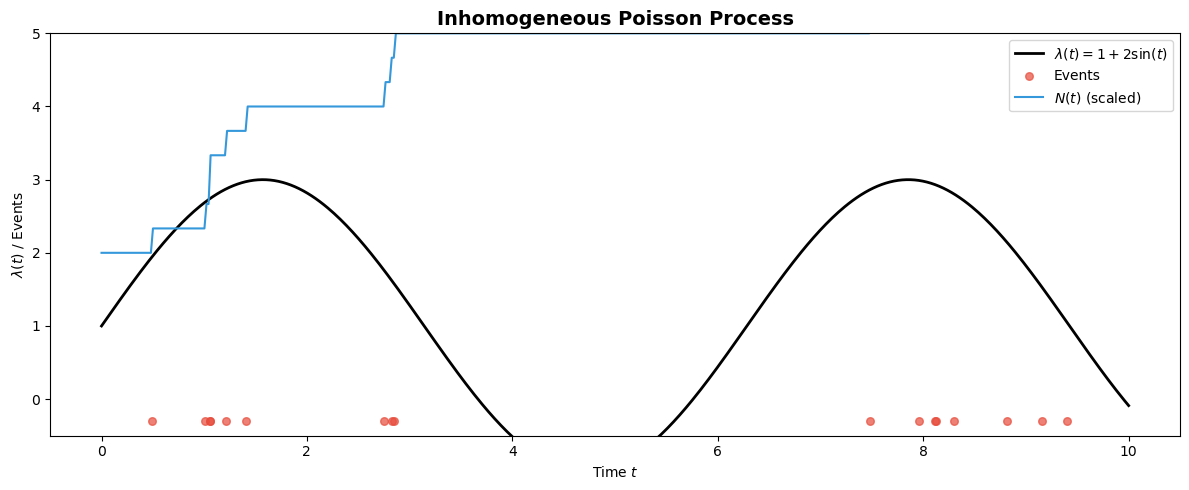

Expected events: 13.7
Actual events: 17


In [32]:
np.random.seed(111)
T = 10.0

def lambda_t(t):
    return 1.0 + 2.0 * np.sin(t)

# Thinning method
lam_max = 3.5
n_expected = int(lam_max * T * 2)
inter_arrivals = np.random.exponential(1.0 / lam_max, size=n_expected)
arrivals_homo = np.cumsum(inter_arrivals)
arrivals_homo = arrivals_homo[arrivals_homo <= T]

keep_probs = lambda_t(arrivals_homo) / lam_max
keep = np.random.rand(len(arrivals_homo)) < keep_probs
arrivals_inhomo = arrivals_homo[keep]

plt.figure(figsize=(12, 5))

t_fine = np.linspace(0, T, 500)
plt.plot(t_fine, lambda_t(t_fine), 'k-', linewidth=2, label=rf'$\lambda(t) = 1 + 2\sin(t)$')
plt.scatter(arrivals_inhomo, np.zeros(len(arrivals_inhomo)) - 0.3, color='#e74c3c', 
           s=30, alpha=0.7, zorder=5, label='Events')

N_inhomo = np.array([np.sum(arrivals_inhomo <= t) for t in t_fine])
plt.plot(t_fine, N_inhomo / 3 + 2, color='#3498db', linewidth=1.5, label=rf'$N(t)$ (scaled)')

plt.title('Inhomogeneous Poisson Process', fontsize=14, fontweight='bold')
plt.xlabel('Time $t$')
plt.ylabel(r'$\lambda(t)$ / Events')
plt.legend(fontsize=10)
plt.ylim(-0.5, 5)
plt.tight_layout()
plt.show()

print(f"Expected events: {np.trapezoid(lambda_t(t_fine), t_fine):.1f}")
print(f"Actual events: {len(arrivals_inhomo)}")


## Compound Poisson Process

Each event has a **random size** (jump). The process accumulates these jumps:

$$X(t) = \sum_{i=1}^{N(t)} Y_i$$

where:
- $N(t)$ = Poisson process with rate $\lambda$
- $Y_i$ = i.i.d. jump sizes, independent of $N(t)$

### Examples

| Application | $Y_i$ interpretation |
|-------------|---------------------|
| **Insurance** | Claim amount |
| **Stock prices** | Jump size in asset price |
| **Queueing** | Service time |
| **Neuroscience** | Synaptic weight |

### Moments

$$\mathbb{E}[X(t)] = \lambda t \cdot \mathbb{E}[Y]$$

$$\text{Var}(X(t)) = \lambda t \cdot \mathbb{E}[Y^2]$$

### Special Case: $Y_i = 1$

Then $X(t) = N(t)$ — the standard Poisson process.


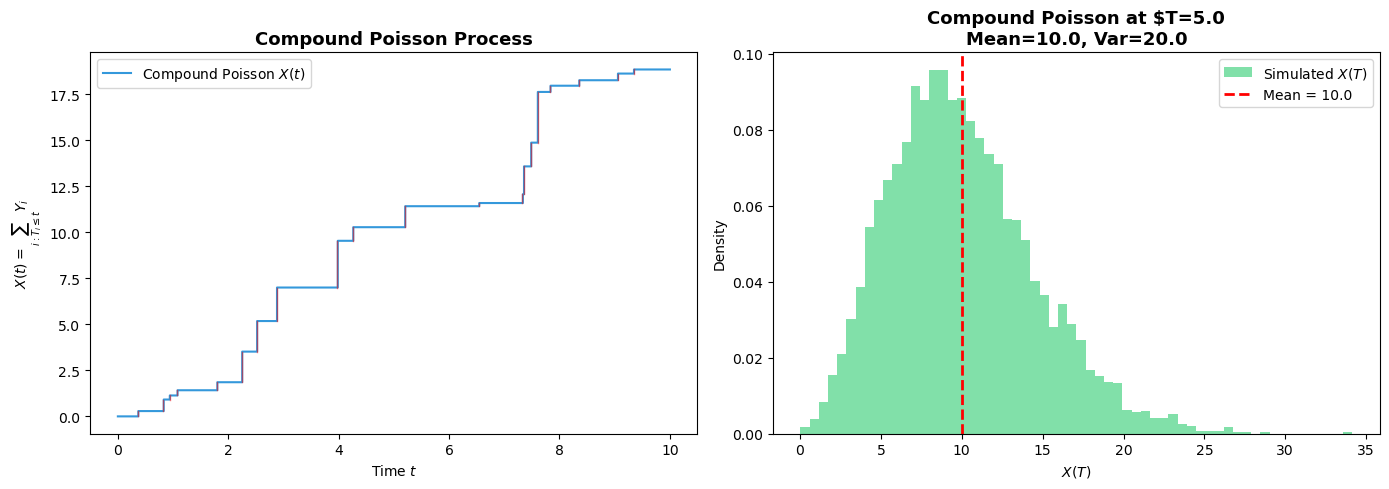

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Compound Poisson path ---
ax = axes[0]
np.random.seed(222)
lam = 2.0
T = 10.0

n_events = np.random.poisson(lam * T)
arrivals = np.sort(np.random.uniform(0, T, n_events))
jumps = np.random.exponential(1.0, n_events)

t_grid = np.linspace(0, T, 1000)
X = np.zeros(len(t_grid))
for j, t in enumerate(t_grid):
    X[j] = np.sum(jumps[arrivals <= t])

ax.step(t_grid, X, where='post', color='#3498db', linewidth=1.5, label=rf'Compound Poisson $X(t)$')
for i in range(min(20, len(arrivals))):
    idx = np.searchsorted(t_grid, arrivals[i])
    if idx < len(t_grid):
        ax.plot([arrivals[i], arrivals[i]], [X[idx] - jumps[i], X[idx]], 
                'r-', alpha=0.5, linewidth=1)
ax.set_title('Compound Poisson Process', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$')
ax.set_ylabel(r'$X(t) = \sum_{i: T_i \leq t} Y_i$')
ax.legend(fontsize=10)

# --- Right: Distribution at T ---
ax = axes[1]
np.random.seed(333)
n_sims = 5000
lam = 2.0
T = 5.0

X_T = []
for _ in range(n_sims):
    n = np.random.poisson(lam * T)
    if n > 0:
        jumps = np.random.exponential(1.0, n)
        X_T.append(np.sum(jumps))
    else:
        X_T.append(0)

ax.hist(X_T, bins=60, density=True, alpha=0.6, color='#2ecc71', label='Simulated $X(T)$')
mean_X = lam * T * 1.0
var_X = lam * T * (1.0 + 1.0**2)
ax.axvline(x=mean_X, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_X:.1f}')
ax.set_title(rf'Compound Poisson at $T={T}' + '\n' + rf'Mean={mean_X:.1f}, Var={var_X:.1f}', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('$X(T)$')
ax.set_ylabel('Density')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


## Spatial Poisson Process

Points scattered randomly in space with density $\lambda$ per unit area.

### Properties

1. **Number of points** in region $A$: $N(A) \sim \text{Poisson}(\lambda \cdot |A|)$
2. **Uniform distribution**: Given $N(A) = n$, the $n$ points are i.i.d. uniform in $A$
3. **Independent increments**: Disjoint regions have independent counts

### Nearest Neighbor Distance

For a Poisson process in 2D with density $\lambda$:

$$P(\text{nearest neighbor} > r) = e^{-\lambda \pi r^2}$$

$$f_R(r) = 2\pi\lambda r \, e^{-\lambda \pi r^2}$$

This is a **Rayleigh distribution** with parameter $\sigma = 1/\sqrt{2\pi\lambda}$.

### Complete Spatial Randomness (CSR)

The spatial Poisson process is the benchmark for "no pattern" — any deviation 
(clustering or regularity) indicates non-random structure.


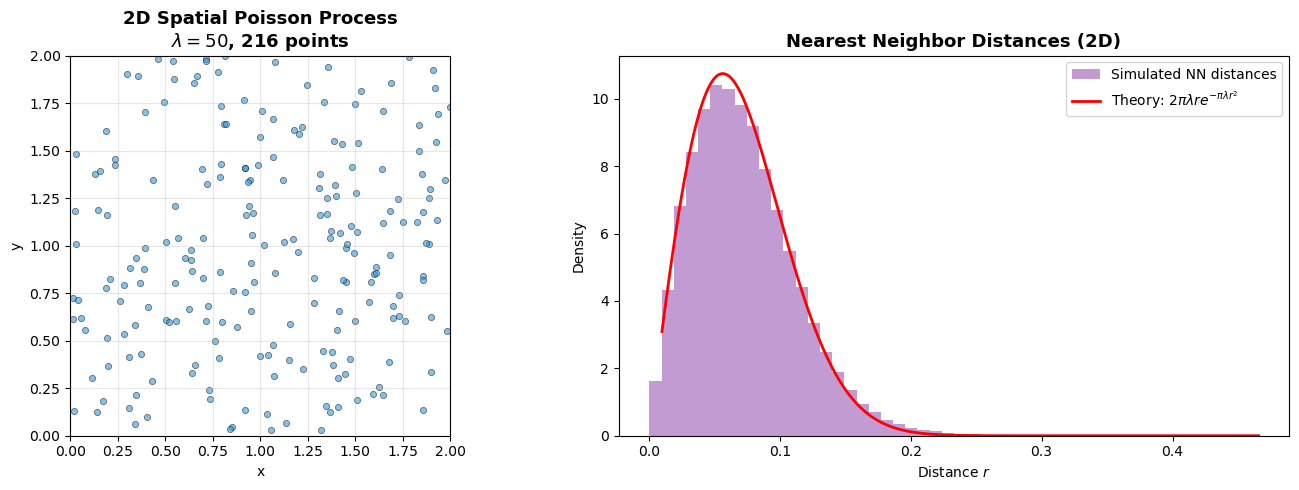

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: 2D scatter ---
ax = axes[0]
np.random.seed(444)
lam_2d = 50  # Points per unit area
n_points = np.random.poisson(lam_2d * 4)  # In [0,2]x[0,2]
x_points = np.random.uniform(0, 2, n_points)
y_points = np.random.uniform(0, 2, n_points)

ax.scatter(x_points, y_points, s=20, alpha=0.6, color='#3498db', edgecolors='black', linewidth=0.5)
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_aspect('equal')
ax.set_title(rf'2D Spatial Poisson Process' + '\n' + rf'$\lambda = {lam_2d}$, {n_points} points', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.3)

# --- Right: Nearest neighbor distances ---
ax = axes[1]
np.random.seed(555)
n_sims = 1000
nn_distances = []

for _ in range(n_sims):
    n = np.random.poisson(lam_2d * 4)
    x = np.random.uniform(0, 2, n)
    y = np.random.uniform(0, 2, n)
    
    if n > 1:
        for i in range(n):
            dists = np.sqrt((x - x[i])**2 + (y - y[i])**2)
            dists = dists[dists > 0]
            if len(dists) > 0:
                nn_distances.append(np.min(dists))

ax.hist(nn_distances, bins=50, density=True, alpha=0.6, color='#9b59b6', label='Simulated NN distances')
r_range = np.linspace(0.01, max(nn_distances), 300)
pdf_approx = 2 * np.pi * lam_2d * r_range * np.exp(-np.pi * lam_2d * r_range**2)
ax.plot(r_range, pdf_approx, 'r-', linewidth=2, label=rf'Theory: $2\pi\lambda r e^{{-\pi\lambda r^2}}$')
ax.set_title('Nearest Neighbor Distances (2D)', fontsize=13, fontweight='bold')
ax.set_xlabel('Distance $r$')
ax.set_ylabel('Density')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


## Application: Merton Jump-Diffusion Model

Asset prices sometimes make sudden jumps (earnings announcements, market crashes). 
The Merton model combines GBM with Poisson jumps:

$$dS(t) = \mu S(t) dt + \sigma S(t) dW(t) + S(t-) dJ(t)$$

where $J(t) = \sum_{i=1}^{N(t)} (e^{Y_i} - 1)$ is a compound Poisson process.

### Solution

Between jumps, the price follows GBM. At each jump time $T_i$:

$$S(T_i) = S(T_i-) \cdot e^{Y_i}$$

### Log-Return Decomposition

$$\ln\left(\frac{S(t)}{S(0)}\right) = \underbrace{\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W(t)}_{\text{diffusion}} + \underbrace{\sum_{i=1}^{N(t)} Y_i}_{\text{jumps}}$$

### Why Jumps Matter

| Feature | Pure GBM | Jump-Diffusion |
|---------|----------|----------------|
| Path continuity | Continuous | Discontinuous |
| Tail risk | Thin tails (log-normal) | Fat tails (leptokurtic) |
| Volatility smile | Symmetric | Skewed |
| Crash probability | Essentially zero | Non-zero |

> **Real-world evidence**: The 1987 crash, COVID-19 crash, and flash crashes 
> cannot be explained by diffusion alone — jumps are essential.


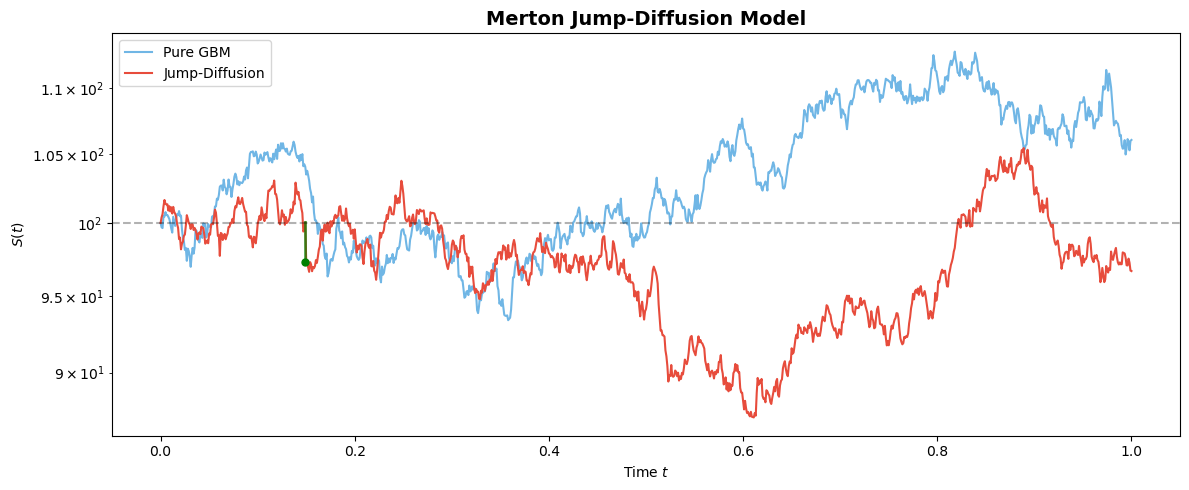

In [20]:
np.random.seed(666)
S0, mu, sigma = 100, 0.05, 0.15
lam_jump = 1.0
mu_jump, sigma_jump = 0.0, 0.1
T, N = 1.0, 1000
dt = T / N
t = np.linspace(0, T, N + 1)

# Diffusion part
dW = np.random.normal(0, np.sqrt(dt), N)
W = np.concatenate([[0], np.cumsum(dW)])

# Jump part
n_jumps = np.random.poisson(lam_jump * T)
jump_times = np.sort(np.random.uniform(0, T, n_jumps))
jump_sizes = np.random.normal(mu_jump, sigma_jump, n_jumps)

# Merton jump-diffusion
S = np.zeros(N + 1)
S[0] = S0
for i in range(N):
    S[i+1] = S[i] * np.exp((mu - 0.5*sigma**2)*dt + sigma*(W[i+1]-W[i]))
    jumps_here = jump_sizes[(jump_times > t[i]) & (jump_times <= t[i+1])]
    for jsize in jumps_here:
        S[i+1] *= np.exp(jsize)

# Pure GBM for comparison
dW2 = np.random.normal(0, np.sqrt(dt), N)
W2 = np.concatenate([[0], np.cumsum(dW2)])
S_gbm = S0 * np.exp((mu - 0.5*sigma**2)*t + sigma * W2)

plt.figure(figsize=(12, 5))
plt.plot(t, S_gbm, color='#3498db', linewidth=1.5, alpha=0.7, label='Pure GBM')
plt.plot(t, S, color='#e74c3c', linewidth=1.5, label='Jump-Diffusion')
for jt, js in zip(jump_times, jump_sizes):
    idx = np.searchsorted(t, jt)
    if idx < len(S):
        plt.plot([jt, jt], [S[idx-1], S[idx]], 'g-', linewidth=2, alpha=0.7)
        plt.plot(jt, S[idx], 'go', markersize=5)
plt.axhline(y=S0, color='black', linestyle='--', alpha=0.3)
plt.title('Merton Jump-Diffusion Model', fontsize=14, fontweight='bold')
plt.xlabel('Time $t$')
plt.ylabel('$S(t)$')
plt.legend(fontsize=10)
plt.yscale('log')
plt.tight_layout()
plt.show()


## Complete Formula Reference

### Homogeneous Poisson Process
- **Inter-arrival times**: $\tau_i \sim \text{Exp}(\lambda)$, $\mathbb{E}[\tau] = 1/\lambda$
- **Count distribution**: $P(N(t) = k) = \frac{(\lambda t)^k}{k!} e^{-\lambda t}$
- **Mean & variance**: $\mathbb{E}[N(t)] = \text{Var}(N(t)) = \lambda t$

### Inhomogeneous Poisson Process
- **Count distribution**: $N(t) - N(s) \sim \text{Poisson}\left(\int_s^t \lambda(u) du\right)$
- **Simulation**: Thinning method with $\lambda_{\max}$

### Compound Poisson Process
- **Definition**: $X(t) = \sum_{i=1}^{N(t)} Y_i$
- **Mean**: $\mathbb{E}[X(t)] = \lambda t \cdot \mathbb{E}[Y]$
- **Variance**: $\text{Var}(X(t)) = \lambda t \cdot \mathbb{E}[Y^2]$

### Spatial Poisson Process (2D)
- **Count in area A**: $N(A) \sim \text{Poisson}(\lambda |A|)$
- **Nearest neighbor CDF**: $P(R > r) = e^{-\lambda \pi r^2}$

### Superposition & Thinning
- **Superposition**: $\lambda_1 + \lambda_2 \to \text{Poisson}(\lambda_1 + \lambda_2)$
- **Thinning**: Keep with prob $p \to \text{Poisson}(\lambda p)$
- 